# Time Series Output Analysis & Visualization

This notebook generates comprehensive time series plots for various environmental parameters including TSS (Total Suspended Sediment), precipitation, wind speed, discharge, and land cover metrics. The visualizations include:
- Raw time series data with markers and trend lines
- Trend analysis annotations with R² values
- Water period categorization with color-coded segments
- Linear/Monotonic trend classification

All plots are generated for both regional and local watersheds.

In [1]:
# Import required libraries for data processing and visualization
import matplotlib.pyplot as plt  # Plotting library
import numpy as np  # Numerical operations
import pandas as pd  # Data manipulation and reading CSV files
import glob  # File path patterns
import os  # Directory and file operations

## 1. Configure Working Directory

Set the path to the merged dataframe directory containing the time series data files for both regional and local watersheds.

In [ ]:
data_dir = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\merged_df"

## 2. Configure Plotting Parameters

Define standard visualization settings for consistency across all plots in the notebook.

In [3]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 15  # Base font size for readability

## 3. Define Core Plotting Function

The `prepare_time_series_plot()` function reads paired CSV files containing time series data and trend analysis, then generates publication-quality plots with:
- Time series visualization with trend lines
- Linear regression analysis with R² goodness-of-fit
- Water period classification with color-coded markers
- Automated trend annotation (Positive/Negative Linear/Monotonic)

In [4]:
def prepare_time_series_plot(paths_var, paths_trend, dict_var, data_dir, color_palette=None):
    """Read paired time-series and trend CSVs and plot them efficiently.

    Parameters
    ----------
    paths_var : list
        List of CSV filepaths containing time series data (must contain 'time_start' and variables)
    paths_trend : list
        List of CSV filepaths with trend information (must contain 'variable' and 'trend' columns)
    dict_var : dict
        Mapping of variable names to {'title': str, 'label': str} for plot annotations
    data_dir : str
        Base directory (used only for path context)
    color_palette : list, optional
        List of colors for water period visualization (default: blue, orange, green, red)
    """
    # Set default color palette for water periods if not provided
    if color_palette is None:
        color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # ========== Main Loop: Process each pair of time series and trend files ==========
    for p_var, p_trend in zip(paths_var, paths_trend):
        # Read time series data and sort by date
        df = pd.read_csv(p_var, parse_dates=['time_start']).sort_values('time_start')

        # Load trend data robustly with error handling for encoding issues
        try:
            df_trend = pd.read_csv(p_trend)
        except Exception:
            df_trend = pd.read_csv(p_trend, encoding='utf-8', engine='python')

        # Clean up trend dataframe
        if 'Unnamed: 0' in df_trend.columns:
            df_trend = df_trend.drop(columns=['Unnamed: 0'])
        if 'variable' in df_trend.columns:
            df_trend = df_trend.set_index('variable')

        axes = df_trend.index.tolist()  # Extract variable names from trend data

        # ========== Create subplot layout (one row per variable) ==========
        fig, axs = plt.subplots(len(axes), 1, figsize=(16, 3 * max(1, len(axes))), squeeze=False)

        # ========== Plot each variable ==========
        for i, var in enumerate(axes):
            ax = axs[i, 0]

            # Check if variable exists in time series data
            if var not in df.columns:
                ax.text(0.5, 0.5, f"{var} not in {os.path.basename(p_var)}", ha='center')
                continue

            # ========== Special handling for land cover area variables ==========
            if ("anthropogenic_km2" in var) or ("natural_km2" in var):
                # Drop duplicate time values (yearly estimates)
                drop_duplicates = df.drop_duplicates(subset=[var])
                series = drop_duplicates[var]
                x = drop_duplicates['time_start']
                
                # Plot raw data with dashed line and markers
                ax.plot(x, series, color='gray', linestyle='-.', linewidth=1, alpha=0.6)
                ax.plot(x, series, marker='o', linestyle='none', markersize=6, color='#9467bd', alpha=0.8, label="Yearly Estimates")
                
                # Calculate and plot linear trend line
                x_ord = x.map(pd.Timestamp.toordinal)
                valid = series.notna() & x_ord.notna()
                if valid.sum() > 1:
                    m, b = np.polyfit(x_ord[valid], series[valid], 1)
                    ax.plot(x, m * x_ord + b, color='black', linestyle='--', linewidth=1)
                else:
                    m = b = np.nan

            # ========== Standard time series plotting (precipitation, discharge, wind, TSS) ==========
            else:
                series = df[var]
                x = df['time_start']
                
                # Plot raw time series with dashed line and light color
                ax.plot(x, series, color='gray', linestyle='-.', linewidth=1, alpha=0.6)

                # Calculate linear trend line using ordinal dates
                x_ord = x.map(pd.Timestamp.toordinal)
                valid = series.notna() & x_ord.notna()
                if valid.sum() > 1:
                    m, b = np.polyfit(x_ord[valid], series[valid], 1)
                    ax.plot(x, m * x_ord + b, color='black', linestyle='--', linewidth=1)
                else:
                    m = b = np.nan

                # ========== Plot by water period with color coding ==========
                if 'water_period' in df.columns:
                    water_periods = sorted(df['water_period'].dropna().unique())
                    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}
                    for wp in water_periods:
                        sub = df[df['water_period'] == wp]
                        ax.plot(sub['time_start'], sub[var], marker='o', linestyle='none', markersize=6, 
                               color=colors[wp], alpha=0.8, label=str(wp))

            # ========== Axis labels and formatting ==========
            ax.set_xlabel('Date')
            ax.set_ylabel(dict_var.get(var, {}).get('label', var))

            # ========== Retrieve and prepare trend annotation text ==========
            trend_text = ''
            try:
                trend_text = df_trend.loc[var, 'trend']
            except Exception:
                trend_text = ''

            # ========== Calculate and display regression statistics ==========
            if not np.isnan(m):
                # Calculate R-squared (coefficient of determination)
                y_pred = m * x_ord[valid] + b
                ss_res = ((series[valid] - y_pred) ** 2).sum()
                ss_tot = ((series[valid] - series[valid].mean()) ** 2).sum()
                r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
                
                r2_text = f"R² = {r_squared:.3f}" if not np.isnan(r_squared) else "R² = N/A"
                
                # Determine trend classification from slope and trend type
                trend_label = "Positive Monotonic Trend" if ((trend_text == 'monotonic') and (m > 0)) \
                            else "Negative Monotonic Trend" if ((trend_text == 'monotonic') and (m < 0)) \
                            else "Positive Linear Trend" if ((trend_text == 'linear') and (m > 0)) \
                            else "Negative Linear Trend" if ((trend_text == 'linear') and (m < 0)) \
                            else 'No-Trend'
                
                # Annotate plot with regression equation and trend classification
                ax.annotate(f"y = {m:.3f}x + {b:.3f} ({trend_label})\nR² = {r_squared:.3f} (n = {int(series.count())})", 
                           xy=(0.01, 0.915), xycoords='axes fraction', fontsize=13)

        # ========== Save and display the figure ==========
        plt.tight_layout()
        sv_path = os.path.join(f"{os.path.dirname(p_trend)}", 
                              f"ts_{os.path.basename(p_var).split('_')[-1].replace('.csv', '.jpeg')}")
        plt.savefig(sv_path, dpi=350)
        plt.show()
        plt.close(fig)

## 4. Define Variable Metadata & Formatting

Create a dictionary mapping variable names to their display titles and axis labels. This ensures consistent labeling across all plots.

In [5]:
# Define metadata for all variables to be plotted
# Each variable entry contains: title (for reference) and label (for y-axis labels with proper units)
dict_var = {
    "TSS_mean": {"title": "TSS", 'label': "TSS (mg/L)"},
    "area_km2": {"title": "Water Surface Area", 'label': "Area (km$^2$)"},
    "precipitation": {"title": "Precipitation", 'label': "Accumulated Precipitation\n(total mm/Hidrological Period)"},
    'u_wind': {"title": "Eastward Wind Speed", 'label': "Eastward Mean Wind Speed\n(m/s)"},
    "v_wind": {"title": "Northward Wind Speed", 'label': "Northward Mean Wind Speed\n(m/s)"},
    'anthropogenic_km2': {"title": "Anthropic Area", 'label': "Anthropic Area (km²)"},
    'natural_km2': {"title": "Natural Area", 'label': "Natural Area (km²)"},
    "mean_discharge": {"title": "Discharge", 'label': "Mean Discharge (m$^3$/s)"}
}

## 5. Generate Time Series Plots

Execute the plotting function for both regional and local watersheds. This will:
1. Find all merged dataframes and corresponding trend analysis files
2. Generate multi-panel figures for each watershed (one panel per variable)
3. Save publication-quality figures (JPEG, 350 dpi) to the trend analysis directory
4. Display plots inline for review

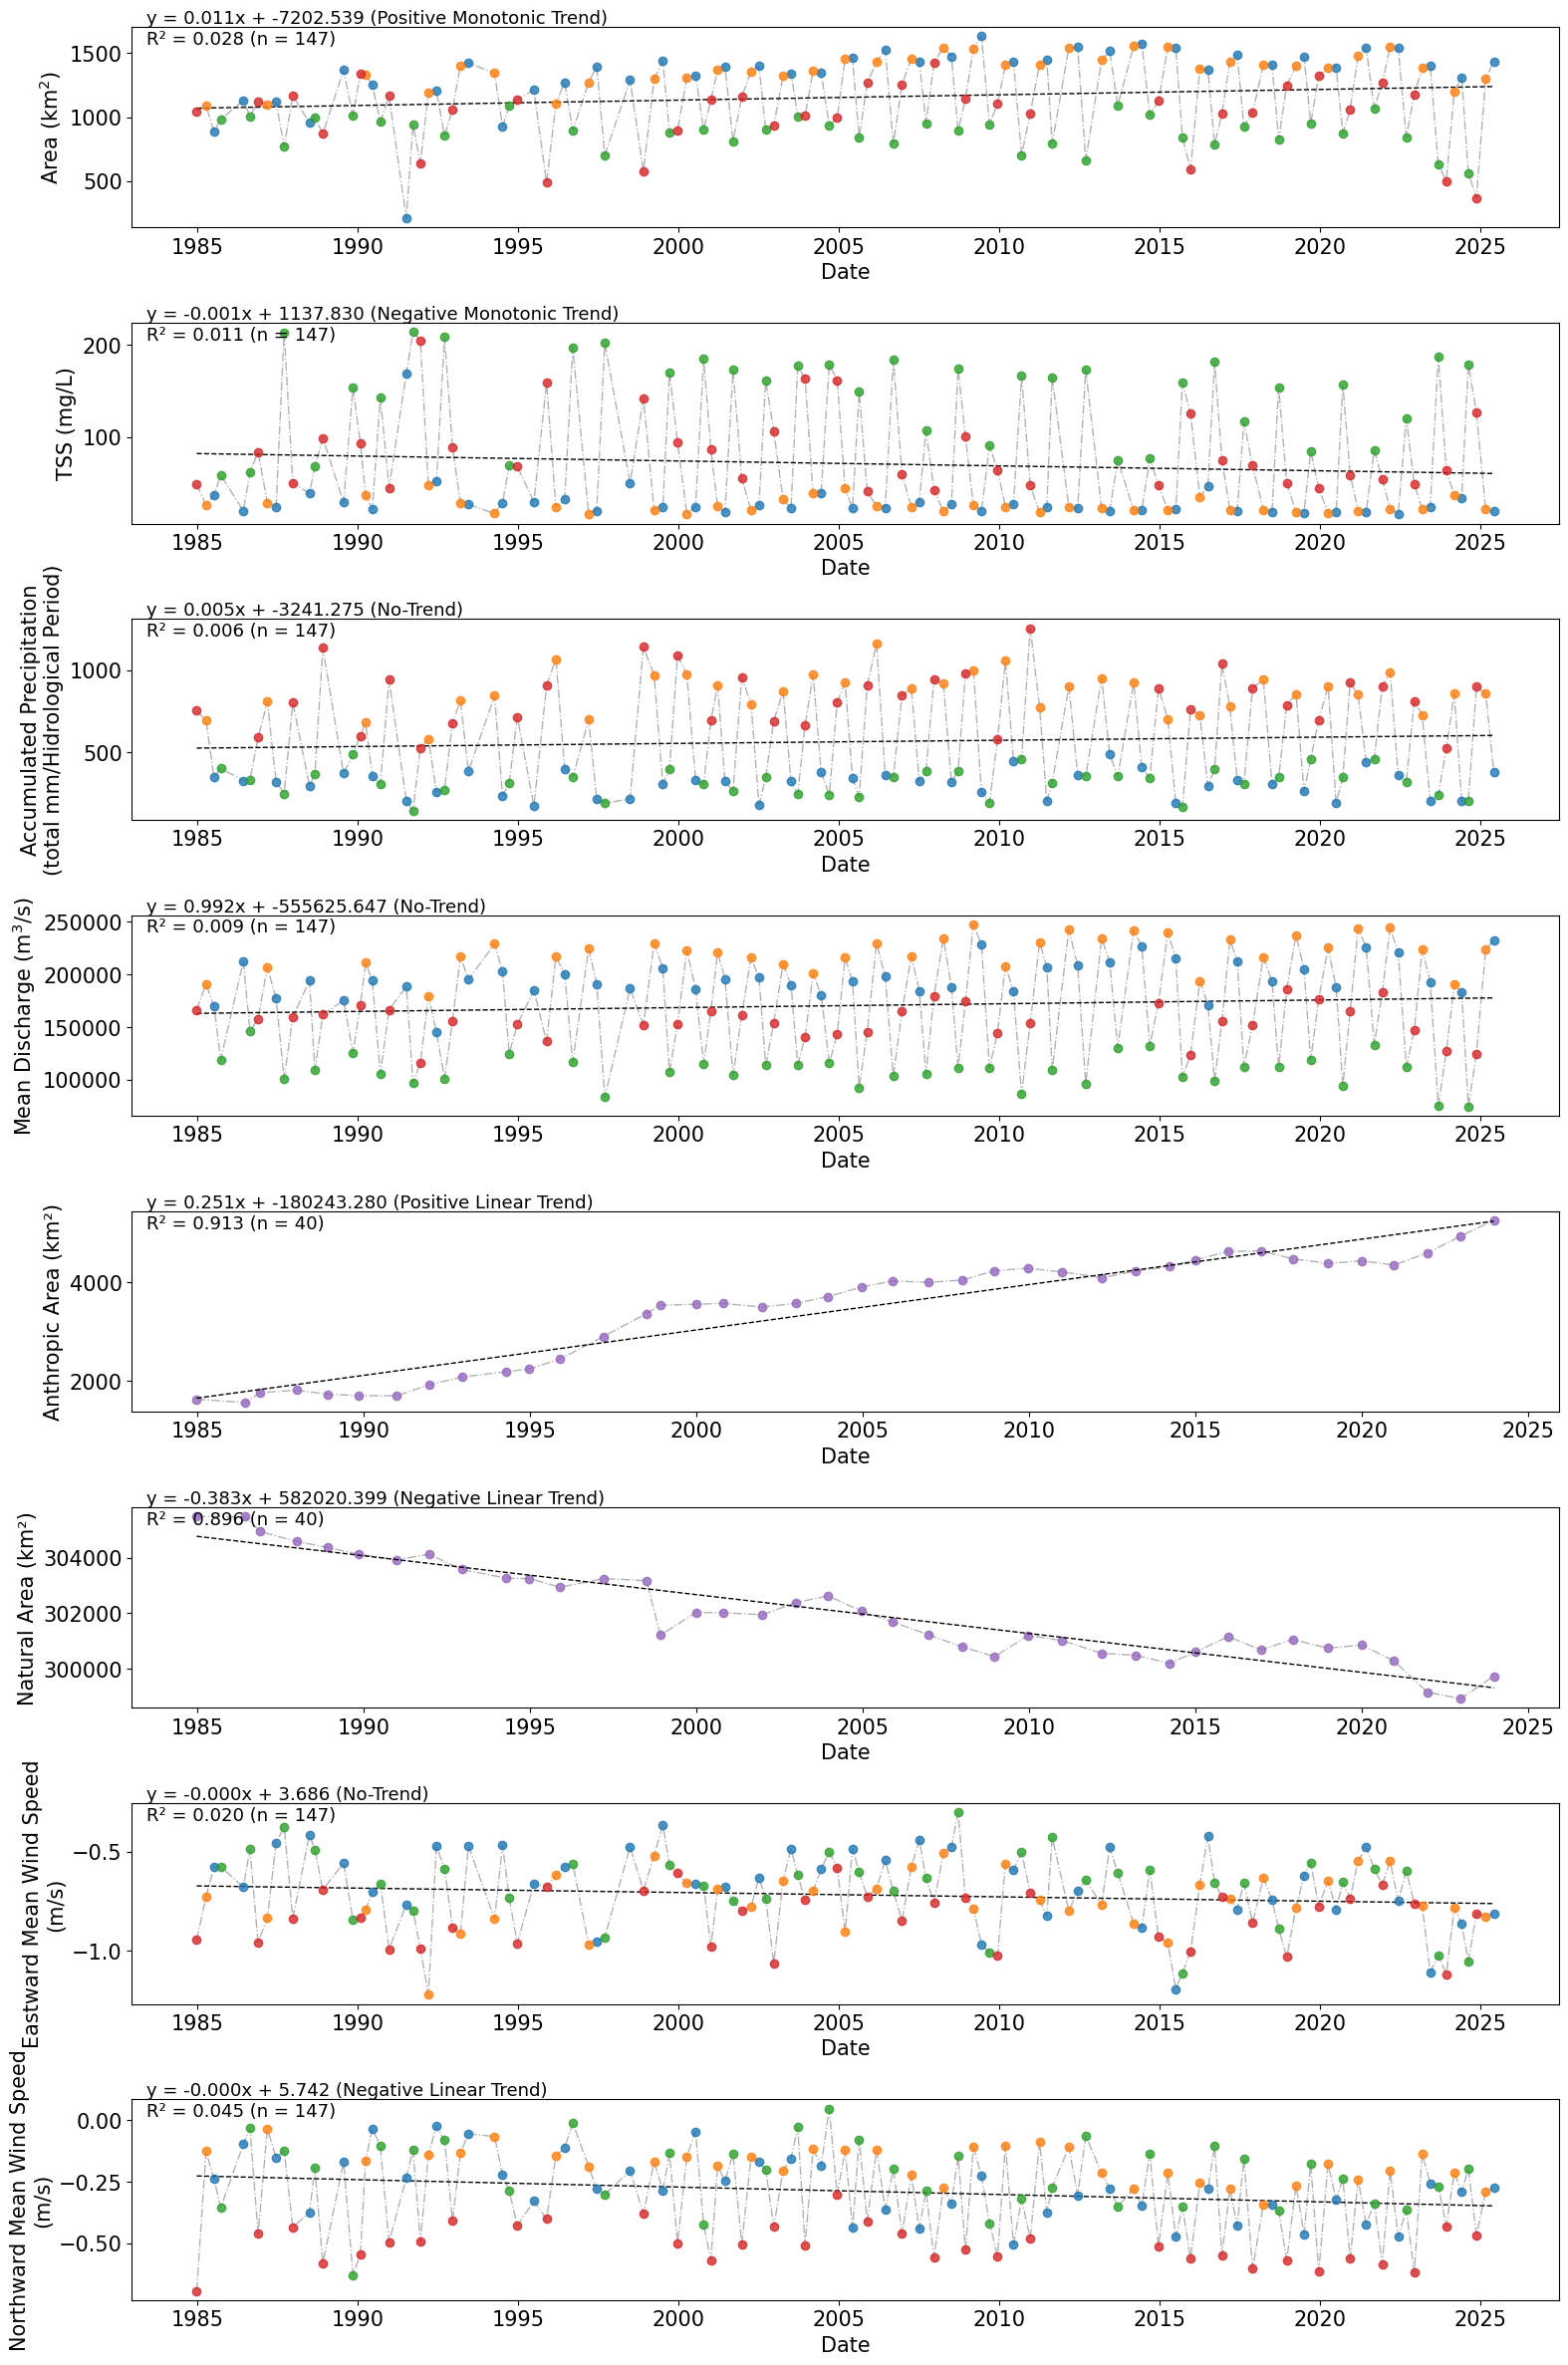

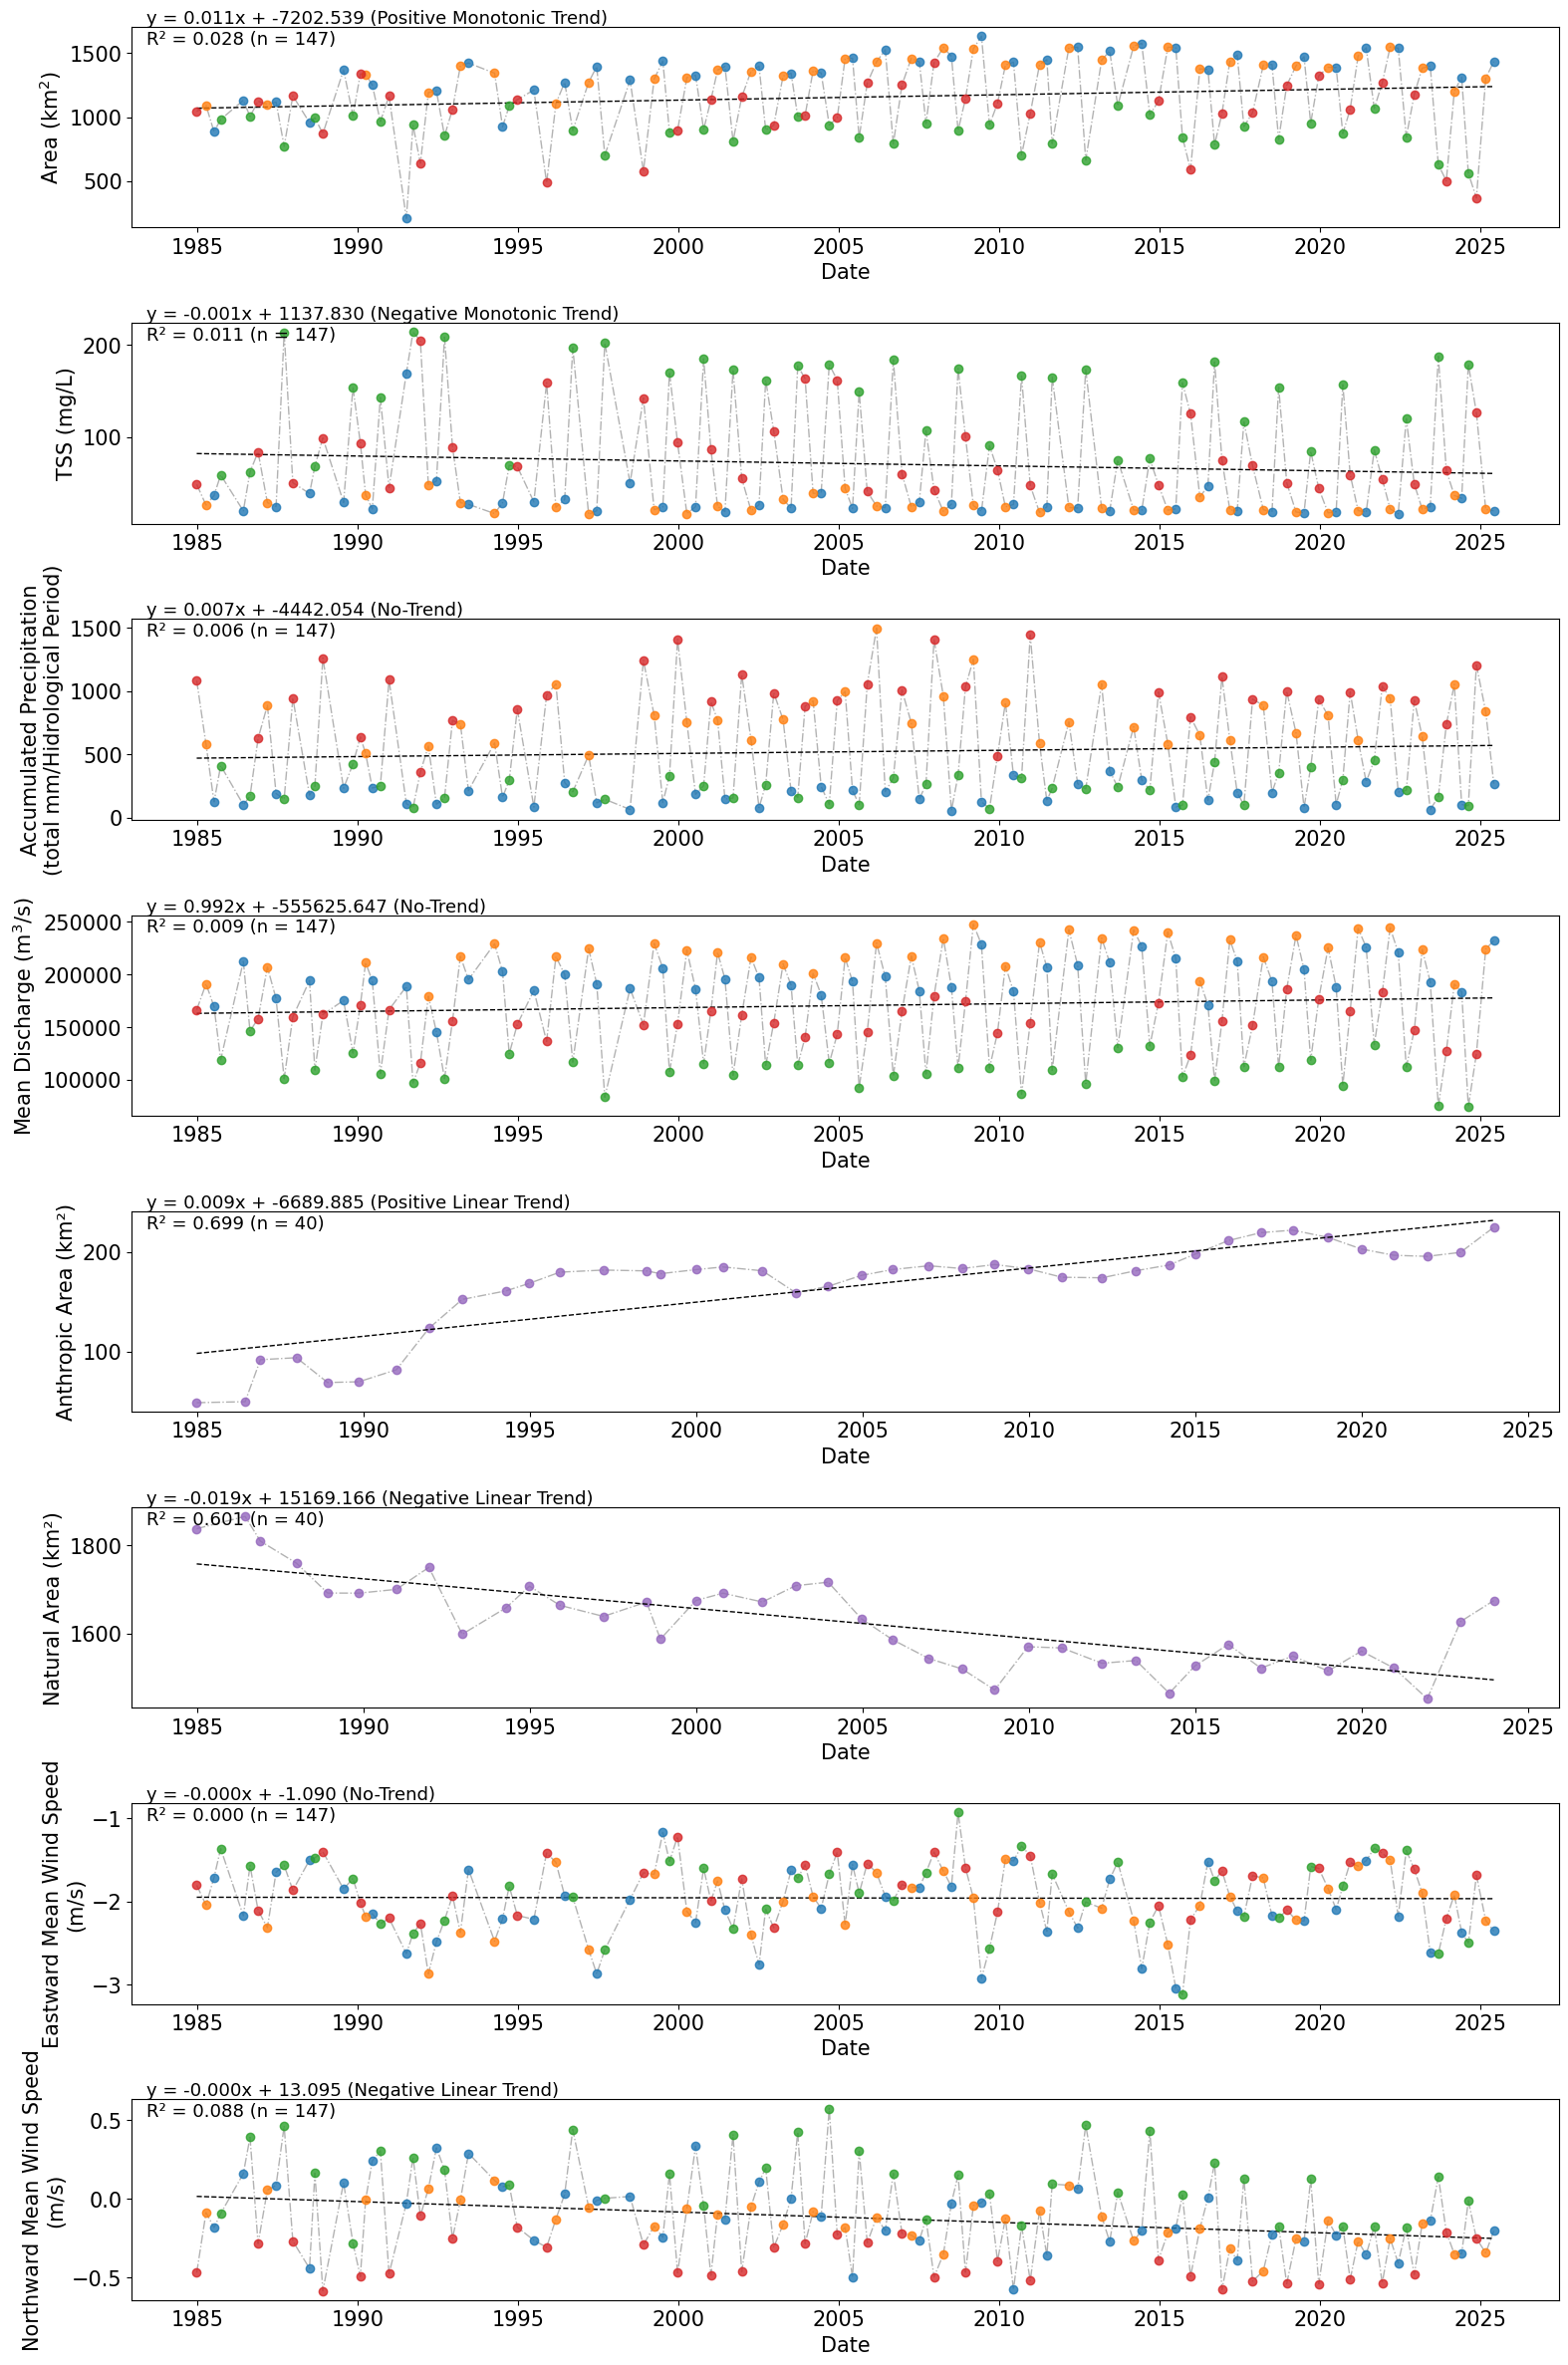

In [6]:
# Define watersheds to process
watersheds = ["regional", "local"]

# ========== Loop through each watershed and generate plots ==========
for watershed in watersheds:
    # Glob patterns to find matching files:
    # - paths_var: merged dataframe CSVs (e.g., df_merged_regional.csv, df_merged_local.csv)
    paths_var = sorted(glob.glob(os.path.join(data_dir, f"*merged*{watershed}.csv")))
    
    # - paths_trend: trend analysis files (e.g., regional_Watershed/trends/...)
    paths_trend = sorted(glob.glob(os.path.join(data_dir, f"{watershed}*Watershed/trends/*al.csv")))
    
    # Call the plotting function to generate and save figures for this watershed
    prepare_time_series_plot(paths_var, paths_trend, dict_var, data_dir)